In [35]:
import numpy as np

from ucimlrepo import fetch_ucirepo
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

def load_glass_data():
    """Load and return the Glass Identification dataset."""
    try:
        glass_data = fetch_ucirepo(id=42)
        X = glass_data.data.features
        y = glass_data.data.targets.values.ravel()

        majority_class = np.bincount(y).argmax()

        y = np.where(y == majority_class, 0, 1)

        return X, y
    except Exception as e:
        print(f"Error loading dataset: {e}")
        raise

X, y = load_glass_data()


Evaluation Results:
Individual fold accuracies: ['0.78', '0.85', '0.78', '0.70', '0.63', '0.81', '0.85', '0.73']
Mean Accuracy: 0.77 ± 0.07
Accuracy Range: 0.63 - 0.85


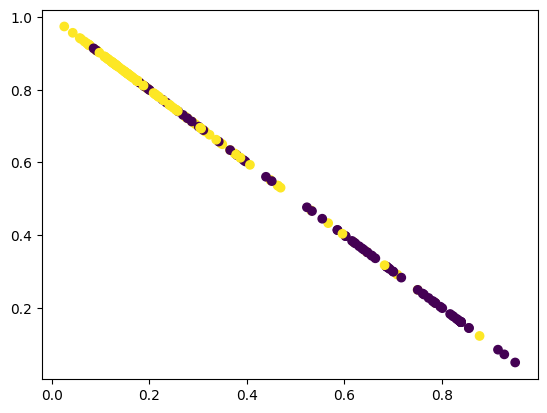

In [36]:
import matplotlib.pyplot as plt

svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(probability=True)
)

# Configure cross-validation strategy
cv = StratifiedKFold(n_splits=8, shuffle=True)

# Perform cross-validation
scores = cross_val_score(svm_pipeline, X, y, cv=cv, n_jobs=-1)

# Report results
print("\nEvaluation Results:")
print(f"Individual fold accuracies: {[f'{s:.2f}' for s in scores]}")
print(f"Mean Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")
print(f"Accuracy Range: {scores.min():.2f} - {scores.max():.2f}")

def plot_likelihood_space(Q0, Q1, y):
    """Plot the likelihood space for the two classes."""
    plt.scatter(Q0, Q1, c=y)
    plt.show()
    plt.close()

svm_pipeline.fit(X, y)
Q = svm_pipeline.predict_proba(X)

Q0, Q1 = Q[:, 0], Q[:, 1]

plot_likelihood_space(Q0, Q1, y)

In [ ]:
def class_likelihood_variance(Q0, Q1, y):
    """Calculate the variance of the class likelihoods."""
    raise NotImplementedError("Variance calculation not implemented")
    return var_C0, var_C1

def class_likelihood_centroid_distance(Q0, Q1, y):
    """Calculate the centroid distance of the class likelihoods."""
    raise NotImplementedError("Centroid distance calculation not implemented")
    return distance

class ModelLikelihoodMetrics:
    var_C0 = 0.0
    var_C1 = 0.0
    centroid_distance = 0.0
